# Principal components analysis

Suppose we conduct an experiment $n$ times and collect $p$ pieces of information from each experiment. Then we can suppose that we collected a dataset $\mathcal{D} = \{ (x_{11},x_{12},\cdots, x_{1p} ), (x_{21},x_{22},\cdots, x_{2p} ),  \cdots, (x_{n1},x_{n2},\cdots, x_{np} )  \}$ and can organize this dataset into the following dataframe 

\begin{align}
    \mathcal{F} = \begin{bmatrix}
        x_{11} & x_{12} & \cdots & x_{1p}\\
        x_{21} & x_{22} & \cdots & x_{2p}\\
        \vdots & \vdots & \vdots & \ddots \\
        x_{n1} & x_{n2} & \cdots & x_{np}\\
        \end{bmatrix}
\end{align}

It is important to acknowledge that a single observation is the tuple $(x_{i1} \cdots x_{1p})$ and so we assume that a tuple of random variables *jointly* generated this single observation. 
In other words, it may not be appropriate to treat each piece of information (often called a covariate) as being generated independently of other covariates: they are generated together.   

The goal of principal components analysis is to find combinations of covariates that "best" describe our original dataset $\mathcal{D}$. 

In this lesson we will aim to understand:
1. How principal components defines "best"
2. The interplay between the (linear) algebra and geometry of principal components
3. How to interpret the outputs of out principal components analysis
4. How principal components analysis differs from linear regression 

## Simulated data 

We will first build a simulated dataset to illustrate the main concepts in principal components analysis. Let the random variables $[X_{1}, X_{2}]$ have a multivariate normal distribution (MVN)

\begin{align}
    &\begin{bmatrix}
        X_{1} \\ 
        X_{2}
    \end{bmatrix} \sim \text{MVN}( \mu, \Sigma ) \\ 
    & \mu    = \begin{bmatrix} -1 \\ 1 \end{bmatrix} ; \; 
    \Sigma  = \begin{bmatrix} 1 & 0.3 \\ 0.3 & 2 \end{bmatrix}
\end{align}

As a recap, the vector $\mu$ decribes the expected value for $X_{1}$ (the value -1) and the expected value for $X_{2}$ (the value 1). 
The *covariance matrix* $\Sigma$ describes the variance for $X_{1}$ (the value 1), the variance for $X_{2}$ (the value 2), and the covariance between $X_{1}$ and $X_{2}$ (the value 0.3).  

We can use `numpy` to  help use generate $n=100$ observations from the above MVN where every observation contains two pieces of information (i.e. two covariates). 
In addition to storing our dataset, we will visualize this information by scatterplotting values of the first covariate versus values of the second covariate. 

Below, you will see two plots side-by-side. 
The first plot includes the scatter (blue circles) as well as a vertical and horizontal line at the values 0 (dashed blue lines). 
Though we typically draw the horizontal and vertical axes for a plot at 0, the value zero is 
arbitrary.
A more reasonable place to draw our axes may be the expected values for the first (-1) and second (1) covariate. We drew those axes as solid blue lines.  

The solid blue lines (expected values) look to be better centered over our dataset than the dashed lines (zeros). 

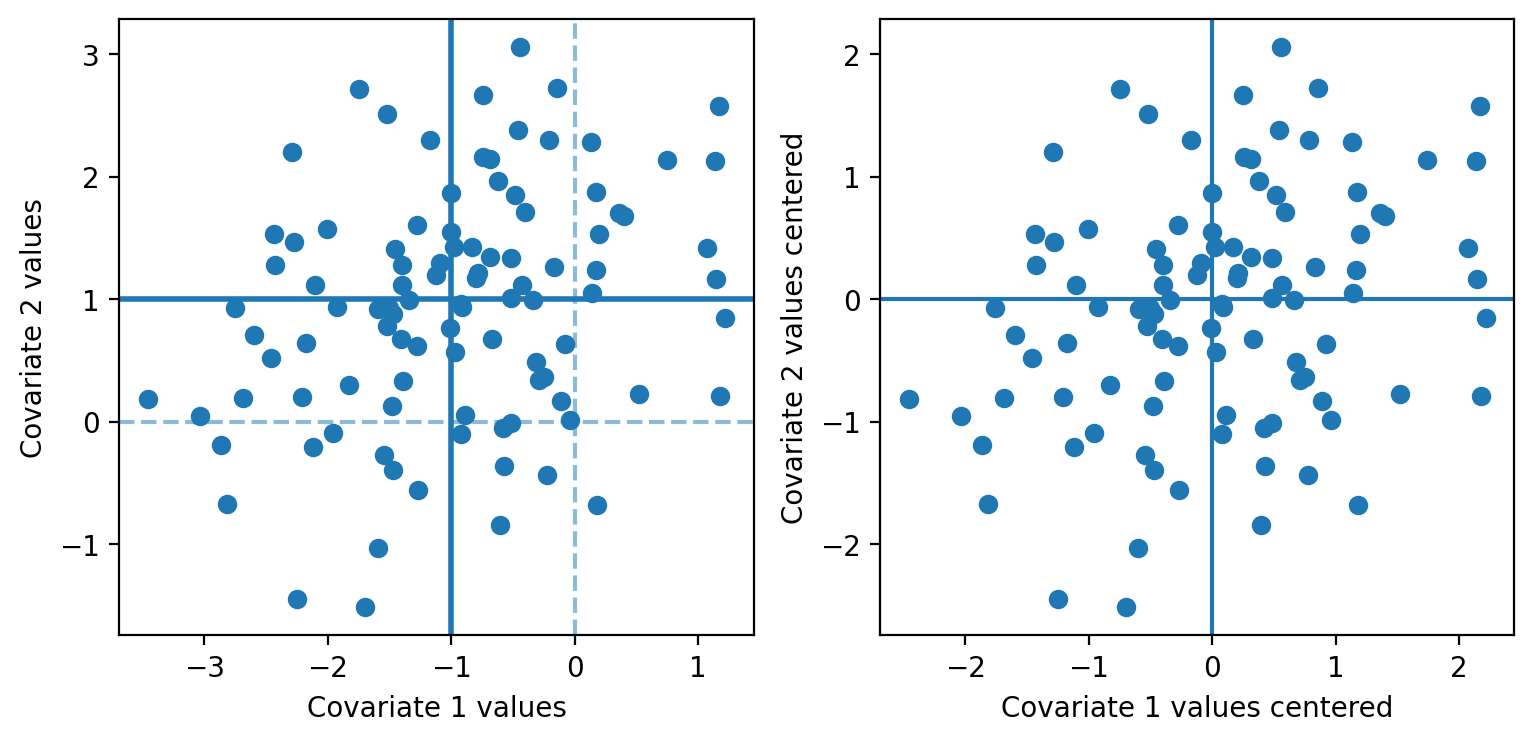

In [8]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

#--Specify the MVN expected value M and the covariance COV
#--Generate 100 observations from this vector of random variables  
M   = np.array([-1,1]) 
COV = np.array([[ 1, 0.3 ], [0.3 , 2]])

#--Note: these three lines are not important to know. 
#--You can just assume that this is the process by which we generate MVN observations. 
L   = np.linalg.cholesky(COV)
z   = np.random.normal( 0,1 ,size = (100,2) )
d   = M + z@L


#--Visualize this dataset 
fig,axs = plt.subplots(1,2)

#--non-centered dataset
ax=axs[0]
ax.scatter(d[:,0], d[:,1])

ax.axhline(0, alpha=0.5, ls="--")
ax.axvline(0, alpha=0.5, ls="--")

ax.axhline(1,lw=2)
ax.axvline(-1,lw=2)

ax.set_xlabel("Covariate 1 values")
ax.set_ylabel("Covariate 2 values")

#--centered dataset
d_centered = d - M #<--subtract the expected value from each covariate

ax=axs[1]

ax.scatter(d_centered[:,0], d_centered[:,1])

ax.axhline(0)
ax.axvline(0)

ax.set_xlabel("Covariate 1 values centered")
ax.set_ylabel("Covariate 2 values centered")

fig.set_size_inches(9,4)

plt.show()

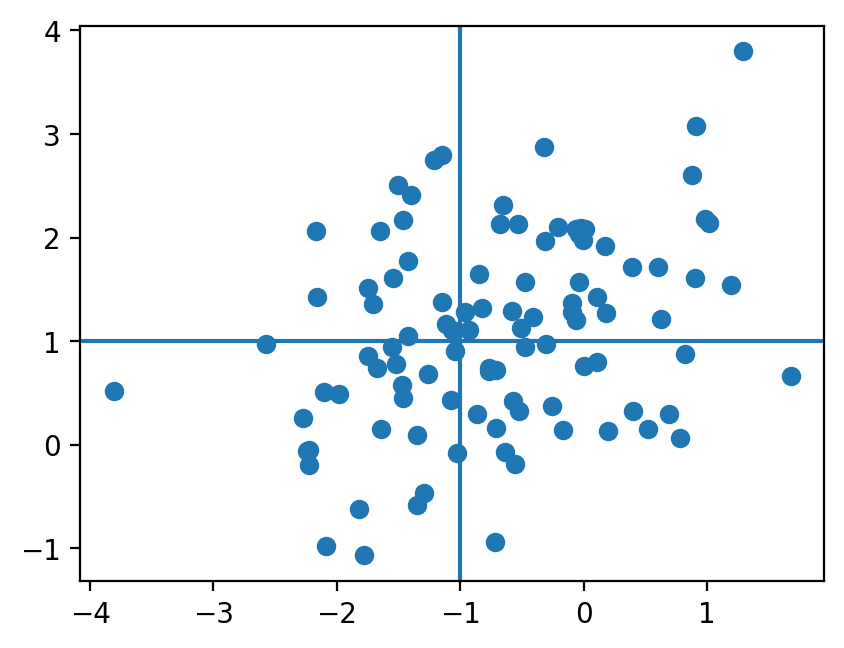

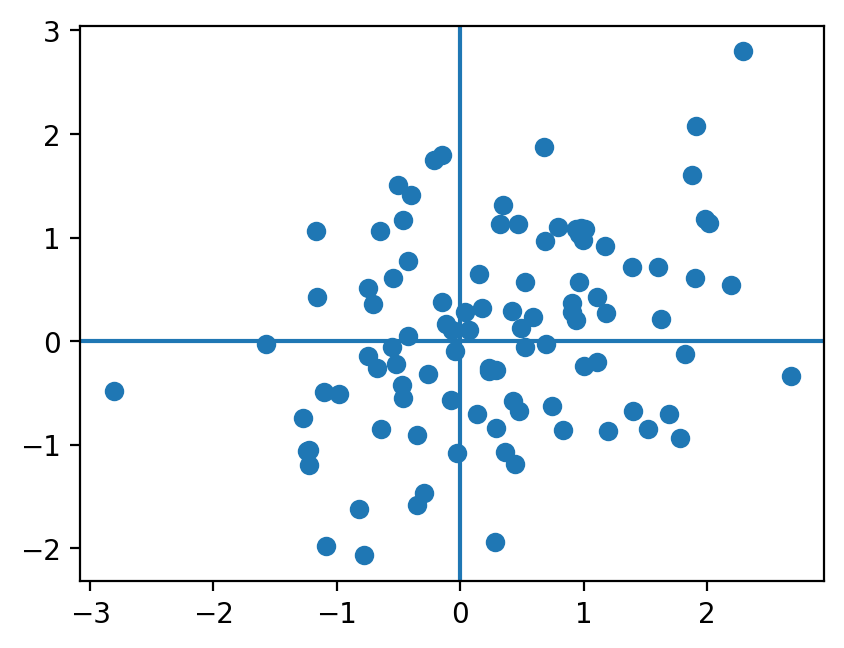

In [4]:
fig,ax = plt.subplots()


ax.scatter(d_centered[:,0], d_centered[:,1])
ax.axhline(0)
ax.axvline(0)



0.9994264883248815
1.0857287139593836


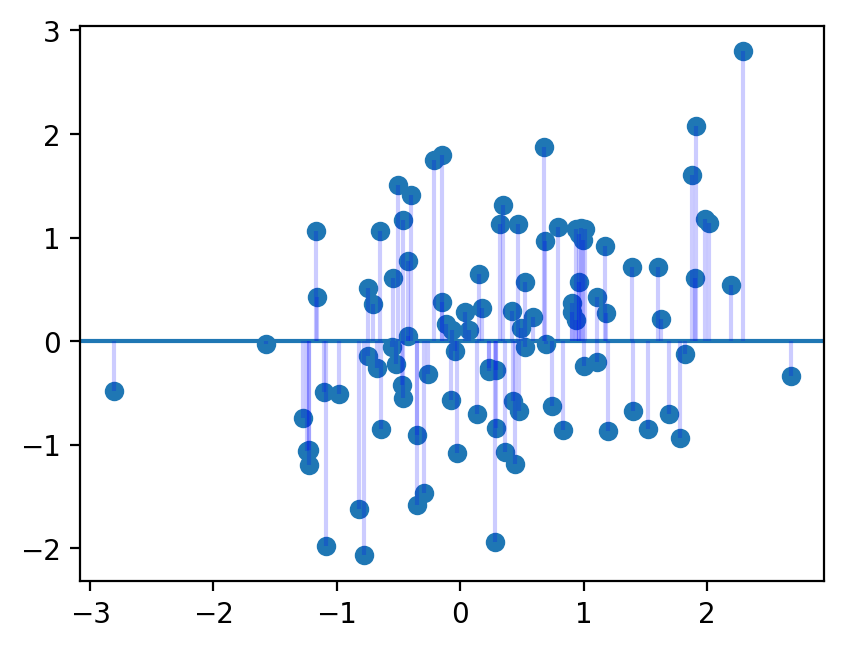

In [5]:
N = len(d_centered)

Var_hline1 = np.var( d_centered[:,0]  )
Var_hline2 = (1/N)*d_centered[:,0].T@d_centered[:,0].T

print(Var_hline1)
print(Var_hline2)

fig,ax = plt.subplots()
ax.scatter(d_centered[:,0], d_centered[:,1])
ax.axhline(0)
ax.vlines(x=d_centered[:,0], ymin=0, ymax=d_centered[:,1], colors='blue',alpha=0.2)


In [6]:

l,u         = np.linalg.eigh(COV)
l_est,u_est = np.linalg.eigh( d_centered.T @ d_centered/N )



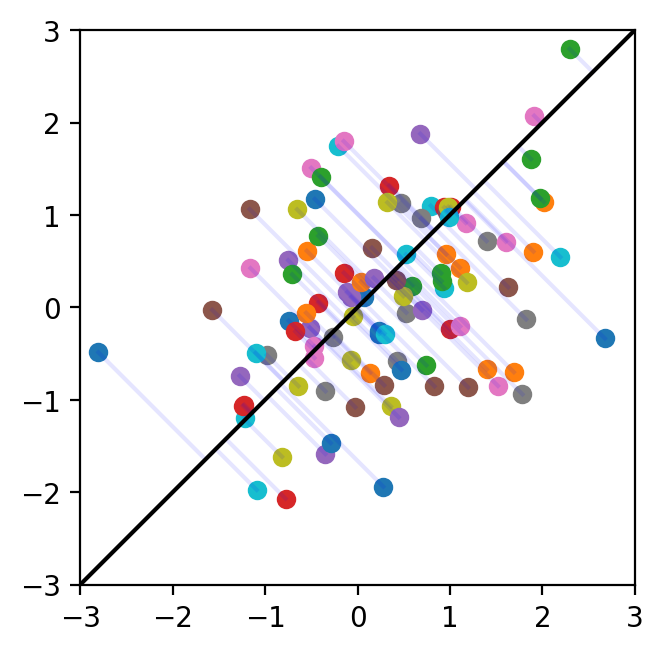

In [7]:

u      = np.array([1,1]).reshape(2,1)
u      = u/np.linalg.norm(u)

alphas = (d_centered @ u) #<-- N X 1

fig, ax = plt.subplots()

for point,alpha in zip(d_centered, alphas):
    alpha = float(alpha)
    u0    = float(u[0])
    u1    = float(u[1])
    ax.plot( [alpha*u0, point[0] ] ,  [alpha*u1, point[1]  ], color="blue", alpha=0.1  )
    ax.scatter( point[0], point[1] )
    
ax.plot( [-3,3], [-3,3], color="black" )  

ax.set_aspect("equal")
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
plt.show()

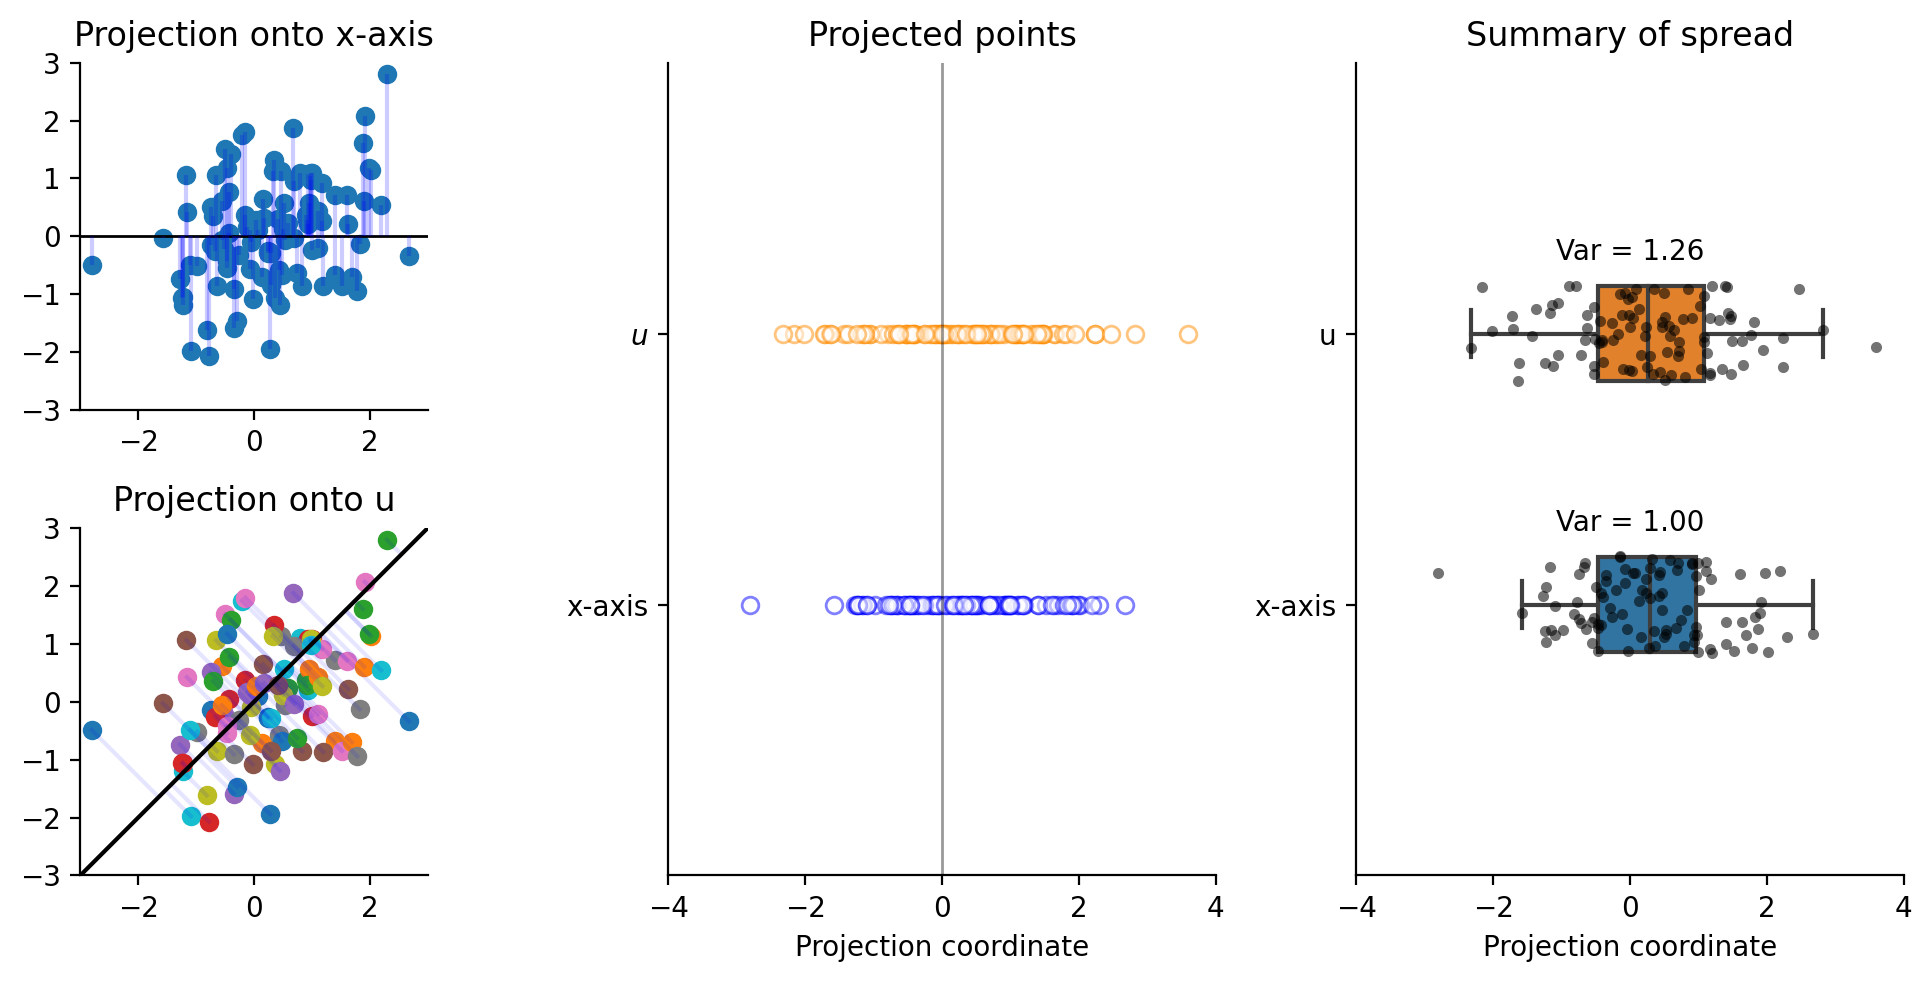

In [20]:
fig = plt.figure(figsize=(10, 5))
gs  = fig.add_gridspec(2, 3)

ax00 = fig.add_subplot(gs[0, 0])
ax10 = fig.add_subplot(gs[1, 0])

ax_proj = fig.add_subplot(gs[:, 1])  # joined second column
ax_box  = fig.add_subplot(gs[:, 2])  # joined third column

# ------------------------------------------------------------
# First row, first column: original data + projection to x-axis
# ------------------------------------------------------------
ax = ax00
ax.scatter(d_centered[:, 0], d_centered[:, 1])
ax.axhline(0, color="black", linewidth=1)
ax.vlines(x=d_centered[:, 0], ymin=0, ymax=d_centered[:, 1],colors="blue",alpha=0.2)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_title("Projection onto x-axis")

# ------------------------------------------------------------
# Second row, first column: original data + projection to u
# ------------------------------------------------------------
u = np.array([1, 1], dtype=float).reshape(2, 1)
u = u / np.linalg.norm(u)

alphas = d_centered @ u          # N x 1
projs  = alphas @ u.T            # N x 2

ax = ax10
for point, proj in zip(d_centered, projs):
    ax.plot([proj[0], point[0]],[proj[1], point[1]],color="blue",alpha=0.1,)
    ax.scatter(point[0], point[1])

ax.plot([-3, 3], [-3, 3], color="black")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_title(r"Projection onto u")

# ------------------------------------------------------------
# Joined second column: compare 1D projected coordinates
# ------------------------------------------------------------
x_proj = d_centered[:, 0]
u_proj = alphas.reshape(-1)

ax = ax_proj

ax.scatter(x_proj
           ,np.zeros_like(x_proj)
           ,facecolor="white",edgecolor="blue",alpha=0.5,label="x-axis")

ax.scatter(u_proj ,np.ones_like(u_proj) ,facecolor="white",edgecolor="darkorange",alpha=0.5,label="u")

ax.set_xlim(-4, 4)
ax.set_ylim(-1, 2)
ax.set_yticks([0, 1])
ax.set_yticklabels(["x-axis", r"$u$"])
ax.axvline(0, color="black", linewidth=1, alpha=0.4)
ax.set_xlabel("Projection coordinate")
ax.set_title("Projected points")

# ------------------------------------------------------------
projected_data = pd.DataFrame({
    "p": np.concatenate([x_proj, u_proj]),
    "projection": ( ["x-axis"] * len(x_proj) + ["u"] * len(u_proj) )})

ax = ax_box

sns.boxplot(x="p"
    ,y="projection"
    ,data=projected_data
    ,ax=ax
    ,width=0.35
    ,showcaps=True
    ,showfliers=False
    #,boxprops={"facecolor": "none", "edgecolor": "black", "linewidth": 1.5}
    #,whiskerprops={"color": "black", "linewidth": 1.2}
    #,capprops={"color": "black", "linewidth": 1.2}
    #,medianprops={"color": "black", "linewidth": 2}
)

sns.stripplot(x="p",y="projection",data=projected_data,ax=ax,jitter=0.18,size=4,alpha=0.55,color="black")

var_xaxis = np.var( x_proj )
var_proj  = np.var( u_proj )

ax.text( 0,1.25, s= "Var = {:.2f}".format(var_proj), va="bottom", ha="center" )
ax.text( 0,0.25, s= "Var = {:.2f}".format(var_xaxis), va="bottom", ha="center" )

ax.set_xlim(-4, 4)
ax.set_ylim(-1,2)
ax.set_xlabel("Projection coordinate")
ax.set_ylabel("")
ax.set_title("Summary of spread")

sns.despine(fig=fig)

plt.tight_layout()
plt.show()

In [9]:
np.var( d_centered[:,0] ) 

0.9994264883248815

In [10]:
np.var(alphas)

1.2606606251860744